In [ ]:
from foswec_flap_base import FOSWECFlapStudyBase

In [ ]:
study = FOSWECFlapStudyBase(wavefreq= 1/2,
                            amplitude=0.1,
)
filename = f"foswec_flap_WOT_f1_{study.f1:.3f}_nf_{study.nfreq}".replace(".", "p") + ".nc"

study.load_or_run_bem(filename)

<xarray.Dataset> Size: 1kB
Dimensions:                (omega: 10, radiating_dof: 1, influenced_dof: 1,
                            wave_direction: 1)
Coordinates:
  * omega                  (omega) float64 80B 3.142 6.283 9.425 ... 28.27 31.42
    freq                   (omega) float64 80B 0.5 1.0 1.5 2.0 ... 4.0 4.5 5.0
    period                 (omega) float64 80B 2.0 1.0 0.6667 ... 0.2222 0.2
  * radiating_dof          (radiating_dof) <U5 20B 'Pitch'
  * influenced_dof         (influenced_dof) <U5 20B 'Pitch'
  * wave_direction         (wave_direction) float64 8B 0.0
    g                      float64 8B 9.81
    rho                    float64 8B 1.025e+03
    body_name              <U22 88B 'copy_of_flap1_immersed'
    water_depth            float64 8B 2.0
    forward_speed          float64 8B 0.0
Data variables:
    added_mass             (omega, radiating_dof, influenced_dof) float64 80B ...
    radiation_damping      (omega, radiating_dof, influenced_dof) float64 80B ...
    diffraction_force      (omega, wave_direction, influenced_dof) complex128 160B ...
    Froude_Krylov_force    (omega, wave_direction, influenced_dof) complex128 160B ...
    excitation_force       (omega, wave_direction, influenced_dof) complex128 160B ...
    inertia_matrix         (influenced_dof, radiating_dof) float64 8B 1.858
    hydrostatic_stiffness  (influenced_dof, radiating_dof) float64 8B 61.98
Attributes: (12/18)
    start_of_computation:                     2026-07-27T14:45:46.654677
    green_function:                           Delhommeau
    tabulation_nr:                            676
    tabulation_rmax:                          100.0
    tabulation_nz:                            372
    tabulation_zmin:                          -251.0
    ...                                       ...
    engine:                                   BasicMatrixEngine
    matrix_cache_size:                        1
    linear_solver:                            lu_decomposition
    method:                                   indirect
    creation_of_dataset:                      2026-07-27T14:45:47.886456
    capytaine_version:                        2.3.1

In [ ]:
study.nfreq

10

In [ ]:
filename

'foswec_flap_WOT_f1_0p500_nf_10.nc'

In [ ]:
results = study.run_mass_sweep([0, 1/2, 1, 3/2, 2], bem_cache_prefix="foswec_1_flap", use_bem_cache=False)

[11:25:16] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

[11:25:27] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

[11:25:31] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

[11:25:36] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

[11:25:41] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

In [ ]:
table = study.results_table(results)

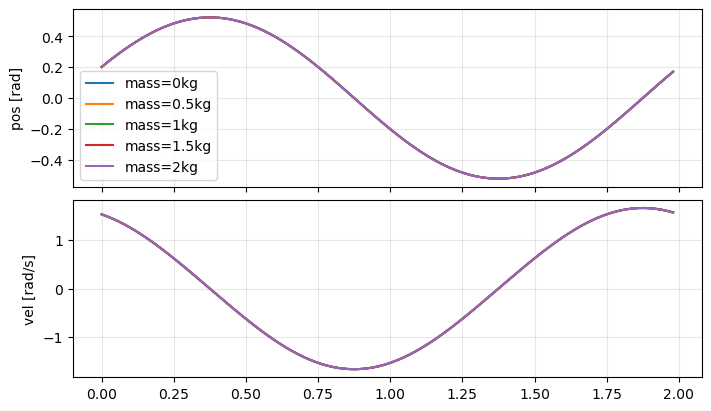

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(7, 4), sharex=True, constrained_layout=True)

for mass, data in results.items():
    wec_tdom = data["wec_tdom"]
    t = wec_tdom.time.values
    pos = wec_tdom["pos"].isel(realization=0, influenced_dof=0).values
    vel = wec_tdom["vel"].isel(realization=0, influenced_dof=0).values

    axs[0].plot(t, pos , label=f"mass={mass}kg")
    axs[1].plot(t, vel, label=f"mass={mass}")

axs[0].set_ylabel("pos [rad]")
axs[1].set_ylabel("vel [rad/s]")

[ax.grid(True, alpha=0.3) for ax in axs.flatten()]
axs[0].legend()

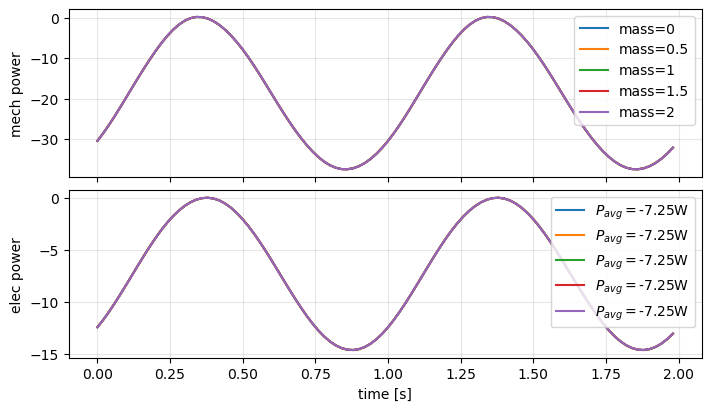

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(7, 4), sharex=True, constrained_layout=True)

for mass, data in results.items():
    pto_tdom = data["pto_tdom"]
    t = pto_tdom.time.values
    pmech = pto_tdom["power"].sel(type="mech").isel(realization=0, dof=0).values
    pelec = pto_tdom["power"].sel(type="elec").isel(realization=0, dof=0).values

    axs[0].plot(t, pmech, label=f"mass={mass}")
    axs[1].plot(t, pelec, label=r"$P_{avg}=$" f"{(pelec.mean()):.2f}W")

axs[0].set_ylabel("mech power")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].set_xlabel("time [s]")
axs[1].set_ylabel("elec power")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

Text(0.5, 1.0, 'FOSWEC, reg wave f = 0.50 Hz, A = 0.10m ')

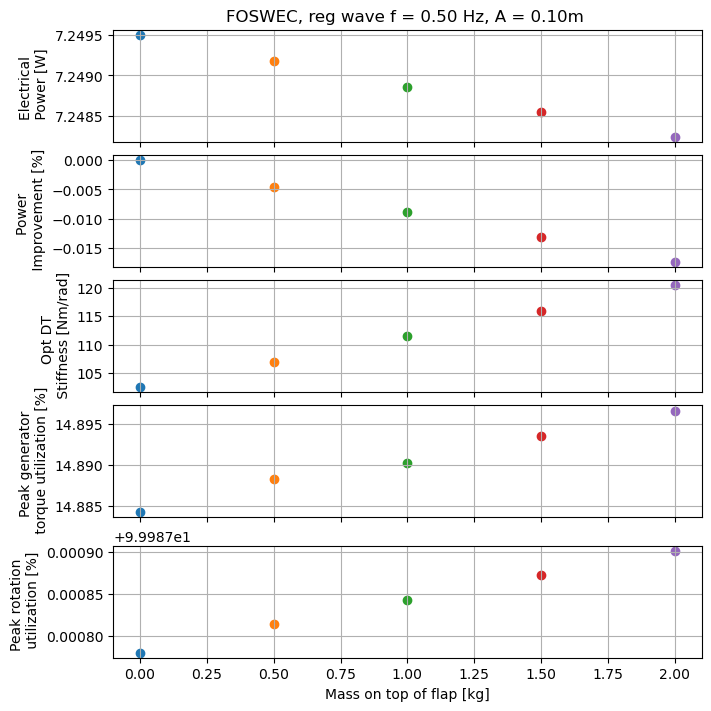

In [ ]:

fig, axs = plt.subplots(5, 1, figsize=(7, 7), sharex=True, constrained_layout=True)

epower0 = -1*results[0]['summary']['opt_power']
for mass, data in results.items():
    smry = data['summary']
    axs[0].scatter(smry['mass_on_top'], -1*smry['opt_power'])
    axs[1].scatter(smry['mass_on_top'], (-1*smry['opt_power']/epower0 -1)*100 )
    axs[2].scatter(smry['mass_on_top'], smry['opt_stiffness'])
    axs[3].scatter(smry['mass_on_top'], data['constraint_metrics']['peak_torque_utilization']*100)
    axs[4].scatter(smry['mass_on_top'], data['constraint_metrics']['peak_rotation_utilization']*100)

[ax.grid() for ax in axs.flatten()]
axs[0].set_ylabel('Electrical \n Power [W]')
axs[1].set_ylabel('Power \n Improvement [%]')

axs[2].set_ylabel('Opt DT \n Stiffness [Nm/rad]')
axs[3].set_ylabel('Peak generator \n torque utilization [%]')
axs[4].set_ylabel('Peak rotation \n utilization [%]')

axs[-1].set_xlabel('Mass on top of flap [kg]')

axs[0].set_title(f'FOSWEC, reg wave f = {study.wavefreq:.2f} Hz, A = {study.amplitude:.2f}m ')

In [ ]:
data['constraint_metrics']

{'max_abs_pos': 0.5235354251740925,
 'max_abs_motor_torque': 6.083776778034669,
 'rms_motor_torque': 4.395404023011342,
 'peak_rotation_margin': 6.335042420635428e-05,
 'peak_torque_margin': 34.75622322196533,
 'rms_torque_margin': 16.024595976988657,
 'peak_rotation_utilization': 0.9998790096020871,
 'peak_torque_utilization': 0.1489661307060399,
 'rms_torque_utilization': 0.2152499521553057,
 'all_constraints_satisfied': True,
 'most_active_constraint_margin': 6.335042420635428e-05}

In [ ]:
#TODO, run for different wave frequencies..
# what is the optimal stiffness mass combo for each frequency? and compare to baseline, also very frequency

In [ ]:
from collections import OrderedDict
import pandas as pd

# User inputs
wavefreq_vec = [1/6, 1/5, 1/4, 1/3, 1/2, 0.75, 1.0]   # Hz
amplitude_vec = [0.025, 0.05, 0.075, 0.10, 0.15]      # m
mass_vec = [0, 1/2, 1, 3/2, 2, 2.5]

bem_cache_prefix = "foswec_1_flap"
use_bem_cache = False

# Main container:
# results_grid[(wavefreq, amplitude)] = {
#     "study": study,
#     "mass_results": ...,
#     "table": ...,
#     "summary_rows": ...
# }
results_grid = OrderedDict()

summary_rows = []

for wavefreq in wavefreq_vec:
    for amplitude in amplitude_vec:
        print(f"Running case: wavefreq={wavefreq:.3f} Hz, amplitude={amplitude:.3f} m")
        filename = (
            f"foswec_flap_WOT_f1_{wavefreq:.3f}_nf_{study.nfreq}"
            .replace(".", "p") + ".nc"
        )
        study = FOSWECFlapStudyBase(
            wavefreq=wavefreq,
            amplitude=amplitude,
        )

        study_base = FOSWECFlapStudyBase(
            wavefreq=wavefreq,
            amplitude=amplitude,
            optimize_stiffness=False,
            fixed_stiffness=0.0,
        )
        study_base.load_or_run_bem(filename)
        baseline_results = study_base.run_mass_sweep([0])

        study.load_or_run_bem(filename)

        mass_results = study.run_mass_sweep(
            mass_vec,
            bem_cache_prefix=bem_cache_prefix,
            use_bem_cache=use_bem_cache,
        )

        table = study.results_table(mass_results)

        case_summary_rows = []
        for mass, data in mass_results.items():
            smry = data["summary"]
            cmet = data.get("constraint_metrics", {})

            row = {
                "wavefreq": wavefreq,
                "amplitude": amplitude,
                "mass_on_top": smry.get("mass_on_top", mass),
                "opt_power": smry.get("opt_power"),
                "opt_stiffness": smry.get("opt_stiffness"),
                "peak_torque_utilization": cmet.get("peak_torque_utilization"),
                "peak_rotation_utilization": cmet.get("peak_rotation_utilization"),
            }

            case_summary_rows.append(row)
            summary_rows.append(row)

        results_grid[(wavefreq, amplitude)] = {
            "study": study,
            "filename": filename,
            "mass_results": mass_results,
            "table": table,
            "summary_rows": case_summary_rows,
        }

summary_df = pd.DataFrame(summary_rows)

print("\nDone.")
print(f"Number of wave/amplitude cases: {len(results_grid)}")
print(f"Number of mass-sweep result rows: {len(summary_df)}")

summary_df

Running case: wavefreq=0.167 Hz, amplitude=0.025 m
Running case: wavefreq=0.167 Hz, amplitude=0.050 m
Running case: wavefreq=0.167 Hz, amplitude=0.075 m
Running case: wavefreq=0.167 Hz, amplitude=0.100 m
Running case: wavefreq=0.167 Hz, amplitude=0.150 m
Running case: wavefreq=0.200 Hz, amplitude=0.025 m
Running case: wavefreq=0.200 Hz, amplitude=0.050 m
Running case: wavefreq=0.200 Hz, amplitude=0.075 m
Running case: wavefreq=0.200 Hz, amplitude=0.100 m
Running case: wavefreq=0.200 Hz, amplitude=0.150 m
Running case: wavefreq=0.250 Hz, amplitude=0.025 m
Running case: wavefreq=0.250 Hz, amplitude=0.050 m
Running case: wavefreq=0.250 Hz, amplitude=0.075 m
Running case: wavefreq=0.250 Hz, amplitude=0.100 m
Running case: wavefreq=0.250 Hz, amplitude=0.150 m
Running case: wavefreq=0.333 Hz, amplitude=0.025 m
Running case: wavefreq=0.333 Hz, amplitude=0.050 m
Running case: wavefreq=0.333 Hz, amplitude=0.075 m
Running case: wavefreq=0.333 Hz, amplitude=0.100 m
Running case: wavefreq=0.333 Hz

[11:47:22] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

[11:47:31] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

[11:47:40] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

[11:47:48] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

...

[12:00:43] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [4 6 7 8 9] to a minimum of 1e-06 N/(m/s)

[12:00:51] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [4 6 7 8 9] to a minimum of 1e-06 N/(m/s)

[12:01:00] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [4 6 7 8 9] to a minimum of 1e-06 N/(m/s)


Done.
Number of wave/amplitude cases: 35
Number of mass-sweep result rows: 210


,wavefreq,amplitude,mass_on_top,opt_power,opt_stiffness,peak_torque_utilization,peak_rotation_utilization
0,0.166667,0.025,0.0,-0.042022,3.577464e-17,0.011364,0.239432
1,0.166667,0.025,0.5,-0.049757,1.671477e-15,0.012321,0.262711
2,0.166667,0.025,1.0,-0.059752,6.091902e-16,0.013448,0.290712
3,0.166667,0.025,1.5,-0.072930,0.000000e+00,0.014799,0.325797
4,0.166667,0.025,2.0,-0.090700,6.662980e-14,0.016407,0.369872
...,...,...,...,...,...,...,...
205,1.000000,0.150,0.5,-6.367496,6.850324e+02,0.140804,0.470204
206,1.000000,0.150,1.0,-6.367496,6.945200e+02,0.140804,0.470204
207,1.000000,0.150,1.5,-6.367496,7.039964e+02,0.140803,0.470204
208,1.000000,0.150,2.0,-6.367496,7.134877e+02,0.140806,0.470204


In [ ]:
def plot_df_res(plot_df, qnty):
    wavefreq_vals = sorted(plot_df["wavefreq"].unique())
    amplitude_vals = sorted(plot_df["amplitude"].unique())

    # -------------------------------------------------------
    # 1) Power vs mass, one subplot per wave frequency
    # -------------------------------------------------------
    fig, axs = plt.subplots(
        1, len(wavefreq_vals), 
        figsize=(2* len(wavefreq_vals),3 ),
        sharey=True,
        constrained_layout=True
    )

    if len(wavefreq_vals) == 1:
        axs = [axs]

    for ax, wf in zip(axs, wavefreq_vals):
        sub = plot_df[plot_df["wavefreq"] == wf]

        for amp in amplitude_vals:
            s = sub[sub["amplitude"] == amp].sort_values("mass_on_top")
            if len(s) == 0:
                continue
            ax.plot(
                s["mass_on_top"],
                s[qnty],
                marker="o",
                label=f"A={amp:.3f} m"
            )
        ax.set_title(f"wf = {wf:.3f} Hz")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Mass on top[kg]")

    axs[0].set_ylabel(qnty)
    axs[-1].legend()

    axs[-1].set_xlabel("Mass on top of flap [kg]")
    plt.tight_layout()
    plt.show()


In [ ]:
improv_df = summary_df.copy()

# Convert to positive generated electrical power
improv_df["elec_power_W"] = -improv_df["opt_power"]
# Choose the baseline mass
baseline_mass = 0

# Baseline power for each (wavefreq, amplitude)
baseline_df = (
    improv_df[improv_df["mass_on_top"] == baseline_mass]
    [["wavefreq", "amplitude", "elec_power_W"]]
    .rename(columns={"elec_power_W": "baseline_power_W"})
)

# Merge baseline back onto all rows
improv_df = improv_df.merge(
    baseline_df,
    on=["wavefreq", "amplitude"],
    how="left"
)

# Percent improvement relative to baseline mass
improv_df["power_improvement_pct"] = (
    (improv_df["elec_power_W"] / improv_df["baseline_power_W"] - 1.0) * 100.0
)

improv_df

,wavefreq,amplitude,mass_on_top,opt_power,opt_stiffness,peak_torque_utilization,peak_rotation_utilization,elec_power_W,baseline_power_W,power_improvement_pct
0,0.166667,0.025,0.0,-0.042022,3.577464e-17,0.011364,0.239432,0.042022,0.042022,0.000000e+00
1,0.166667,0.025,0.5,-0.049757,1.671477e-15,0.012321,0.262711,0.049757,0.042022,1.840748e+01
2,0.166667,0.025,1.0,-0.059752,6.091902e-16,0.013448,0.290712,0.059752,0.042022,4.219240e+01
3,0.166667,0.025,1.5,-0.072930,0.000000e+00,0.014799,0.325797,0.072930,0.042022,7.355208e+01
4,0.166667,0.025,2.0,-0.090700,6.662980e-14,0.016407,0.369872,0.090700,0.042022,1.158388e+02
...,...,...,...,...,...,...,...,...,...,...
205,1.000000,0.150,0.5,-6.367496,6.850324e+02,0.140804,0.470204,6.367496,6.367496,-2.313656e-08
206,1.000000,0.150,1.0,-6.367496,6.945200e+02,0.140804,0.470204,6.367496,6.367496,1.641904e-08
207,1.000000,0.150,1.5,-6.367496,7.039964e+02,0.140803,0.470204,6.367496,6.367496,-8.264760e-08
208,1.000000,0.150,2.0,-6.367496,7.134877e+02,0.140806,0.470204,6.367496,6.367496,-4.783995e-08


C:\Users\jtgrasb\AppData\Local\Temp\ipykernel_4884\1323149626.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


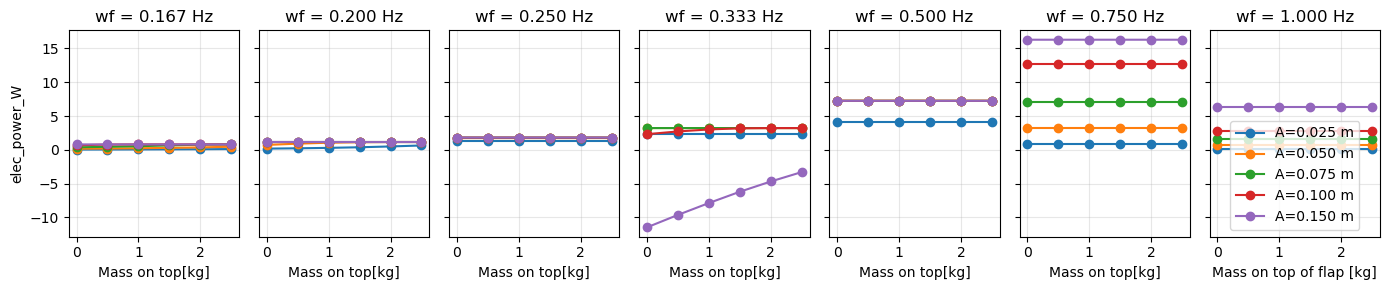

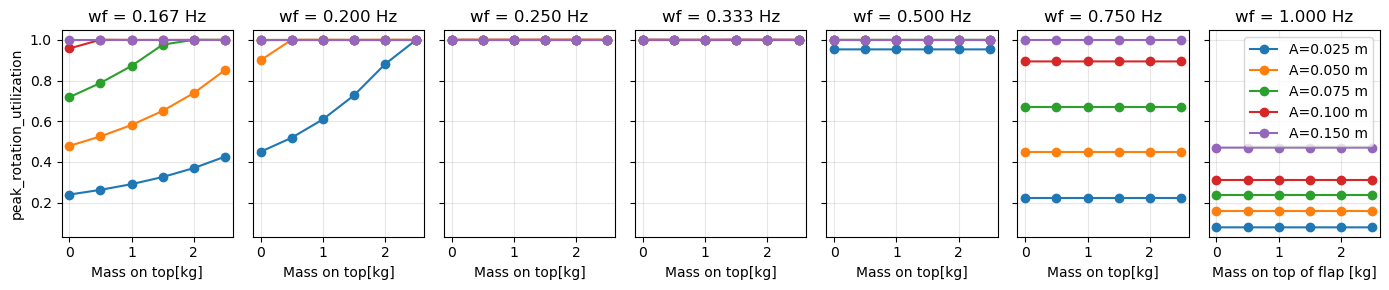

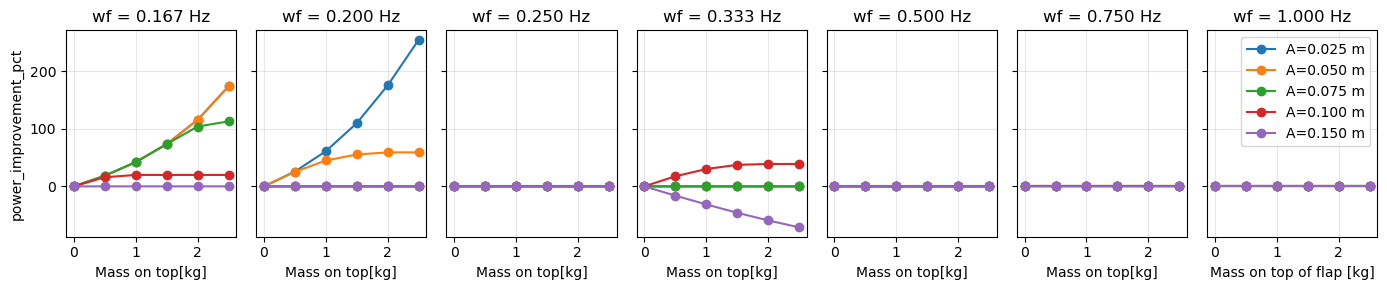

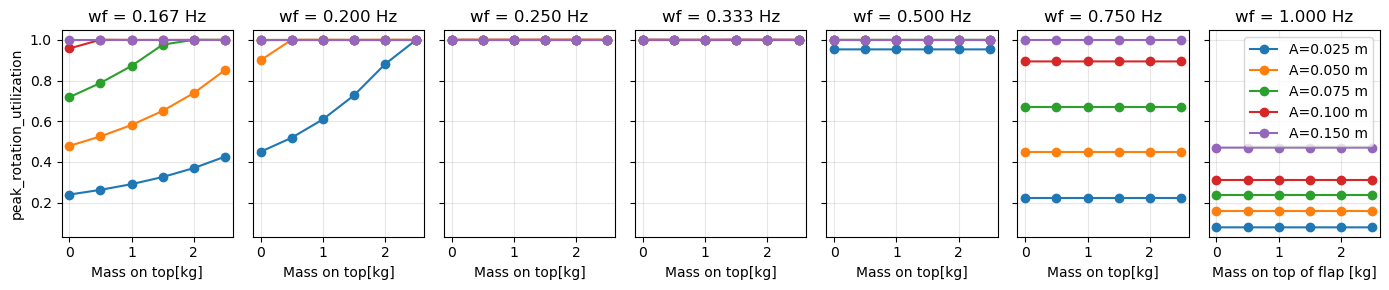

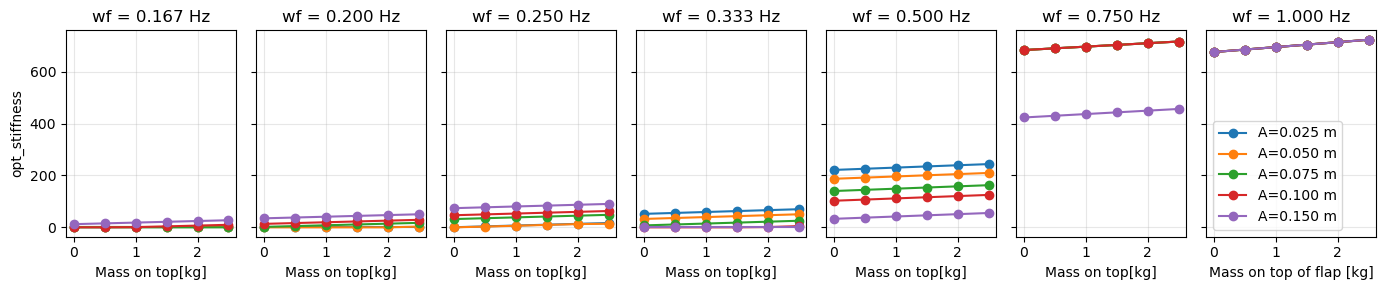

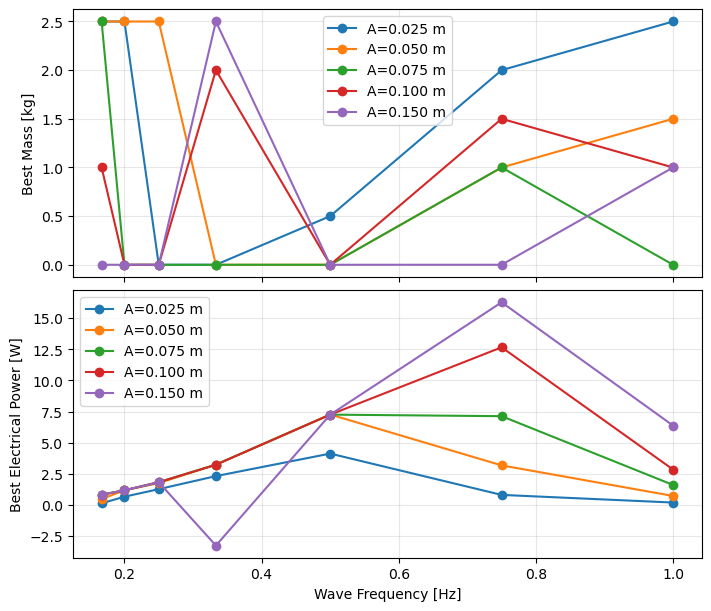

In [ ]:
# Copy and clean
plot_df = summary_df.copy()

# Convert to positive generated electrical power if opt_power is stored negative
plot_df["elec_power_W"] = -plot_df["opt_power"]

# Sort for cleaner plotting
plot_df = plot_df.sort_values(["wavefreq", "amplitude", "mass_on_top"]).reset_index(drop=True)

wavefreq_vals = sorted(plot_df["wavefreq"].unique())
amplitude_vals = sorted(plot_df["amplitude"].unique())


plot_df_res(plot_df, "elec_power_W")
plot_df_res(plot_df, "peak_rotation_utilization")
plot_df_res(improv_df, "power_improvement_pct")
plot_df_res(improv_df, "peak_rotation_utilization")


plot_df_res(plot_df, "opt_stiffness")

# -------------------------------------------------------
# 3) Best mass for each (wavefreq, amplitude)
# -------------------------------------------------------
idx = plot_df.groupby(["wavefreq", "amplitude"])["elec_power_W"].idxmax()
best_df = plot_df.loc[idx].sort_values(["wavefreq", "amplitude"]).reset_index(drop=True)

fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True, constrained_layout=True)

for amp in amplitude_vals:
    s = best_df[best_df["amplitude"] == amp].sort_values("wavefreq")
    if len(s) == 0:
        continue

    axs[0].plot(
        s["wavefreq"],
        s["mass_on_top"],
        marker="o",
        label=f"A={amp:.3f} m"
    )
    axs[1].plot(
        s["wavefreq"],
        s["elec_power_W"],
        marker="o",
        label=f"A={amp:.3f} m"
    )

axs[0].set_ylabel("Best Mass [kg]")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].set_xlabel("Wave Frequency [Hz]")
axs[1].set_ylabel("Best Electrical Power [W]")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.show()

In [ ]:
plot_df

,wavefreq,amplitude,mass_on_top,opt_power,opt_stiffness,peak_torque_utilization,peak_rotation_utilization,elec_power_W
0,0.166667,0.025,0.0,-0.042022,3.577464e-17,0.011364,0.239432,0.042022
1,0.166667,0.025,0.5,-0.049757,1.671477e-15,0.012321,0.262711,0.049757
2,0.166667,0.025,1.0,-0.059752,6.091902e-16,0.013448,0.290712,0.059752
3,0.166667,0.025,1.5,-0.072930,0.000000e+00,0.014799,0.325797,0.072930
4,0.166667,0.025,2.0,-0.090700,6.662980e-14,0.016407,0.369872,0.090700
...,...,...,...,...,...,...,...,...
205,1.000000,0.150,0.5,-6.367496,6.850324e+02,0.140804,0.470204,6.367496
206,1.000000,0.150,1.0,-6.367496,6.945200e+02,0.140804,0.470204,6.367496
207,1.000000,0.150,1.5,-6.367496,7.039964e+02,0.140803,0.470204,6.367496
208,1.000000,0.150,2.0,-6.367496,7.134877e+02,0.140806,0.470204,6.367496
